# The GST operator — minimal implementation and its validation

How short can an honest gradient-structure-tensor operator be? This notebook
uses [gst_operator.py](gst_operator.py), which computes the three OrientationJ
features with **separable Gaussian derivatives in the space domain** — no
Fourier transform, no spline prefilter, no boundary trick beyond mirroring:

```python
C, E, theta = features(image, sigma=2.0, sigma_gradient=1.0)
```

Two widths control everything: `sigma_gradient` for the derivative and `sigma`
for the tensor window. The notebook answers three questions:

1. **Is it exact?** On patterns whose orientation is known analytically.
2. **Does it agree with the plugin?** Against the faithful
   [Python port](../orientationj_python_port) of OrientationJ, on the 16 test
   images.
3. **Where does it differ, and why?** As a function of the structure size.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile

sys.path.insert(0, os.path.join('..', 'orientationj_python_port'))
import orientationj as oj

from gst_operator import features, gradient, gaussian_kernels

SIGMA = 2.0          # tensor window, both implementations
SIGMA_GRADIENT = 1.0  # Gaussian derivative of the minimal operator
INPUT = os.path.join('..', '..', 'test-images')
ACCENT, SECOND = '#4878a8', '#db3f2e'

plt.rcParams.update({
    'figure.facecolor': 'white', 'font.size': 10, 'axes.titlesize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#cfcec6', 'grid.color': '#e8e8e4', 'grid.linewidth': 0.8,
    'text.color': '#3a3a37', 'axes.labelcolor': '#3a3a37',
    'xtick.color': '#6b6a63', 'ytick.color': '#6b6a63'})


def axial_difference(a, b):
    """Signed difference of two orientation maps in degrees, modulo 180."""
    return np.degrees(np.angle(np.exp(2j * (a - b)))) / 2.0


names = sorted(f[:-4] for f in os.listdir(os.path.join(INPUT, 'images'))
               if f.endswith('.tif'))
print(len(names), 'test images')

16 test images


## 1. Is it exact?

The kernels first: the smoothing kernel must sum to 1 and the derivative kernel
must differentiate exactly, which is the normalization
\\(-\\sum_k x_k d(x_k) = 1\\). Then the operator is run on sinusoidal
gratings whose orientation is imposed, and on the radial chirp, whose tangential
orientation is known at every pixel.

In [2]:
g, d = gaussian_kernels(SIGMA_GRADIENT)
x = np.arange(-(len(g) // 2), len(g) // 2 + 1)
print(f'smoothing kernel: sum = {g.sum():.12f}   (must be 1)')
print(f'derivative kernel: -sum(x d) = {-np.sum(x * d):.12f}   (must be 1)')

rows = []
ny = nx = 256
yy, xx = np.mgrid[0:ny, 0:nx].astype(float)
for target in (-75, -60, -45, -30, 0, 30, 45, 60, 75):
    t = np.radians(target)
    grating = np.sin(2.0 * np.pi * 0.06 * (np.sin(t) * xx + np.cos(t) * yy))
    C, E, theta = features(grating, sigma=SIGMA, sigma_gradient=SIGMA_GRADIENT)
    core = (slice(40, -40), slice(40, -40))
    rows.append({'target [deg]': target,
                 'measured [deg]': round(float(np.degrees(np.median(theta[core]))), 4),
                 'max error [deg]': round(float(np.abs(axial_difference(
                     theta[core], np.radians(target))).max()), 6),
                 'coherency': round(float(np.median(C[core])), 6)})
pd.DataFrame(rows)

smoothing kernel: sum = 1.000000000000   (must be 1)
derivative kernel: -sum(x d) = 1.000000000000   (must be 1)


,target [deg],measured [deg],max error [deg],coherency
0,-75,-75.0004,0.000373,1.0
1,-60,-60.0004,0.000373,1.0
2,-45,-45.0000,0.000000,1.0
3,-30,-29.9996,0.000373,1.0
4,0,0.0000,0.000000,1.0
5,30,29.9996,0.000373,1.0
6,45,45.0000,0.000000,1.0
7,60,60.0004,0.000373,1.0
8,75,75.0004,0.000373,1.0


In [3]:
# radial chirp: tangential truth, in the doubled-angle form of the tensor
# (same convention as the gradient assessment)
FMIN, FMAX = 0.02, 0.16          # chirp() of synthetic_images_2D
SIZE = 1024
image = oj.load(os.path.join(INPUT, 'images', 'synthetic_chirp_1024.tif'))
mask = tifffile.imread(os.path.join(INPUT, 'masks',
                                    'synthetic_chirp_1024.tif')) > 0
yy, xx = np.mgrid[0:SIZE, 0:SIZE].astype(float)
dx, dy = xx - SIZE / 2, yy - SIZE / 2
radius = np.hypot(dx, dy)
truth = 0.5 * np.arctan2(2.0 * dx * dy, dy * dy - dx * dx)   # radians

C, E, theta = features(image, sigma=SIGMA, sigma_gradient=SIGMA_GRADIENT)
error = np.abs(axial_difference(theta, truth))[mask]
print(f'chirp, inside the mask: median error {np.median(error):.3f} deg, '
      f'90th percentile {np.percentile(error, 90):.3f} deg')

chirp, inside the mask: median error 0.001 deg, 90th percentile 0.001 deg


## 2. Does it agree with the plugin?

The reference is the Python port, which reproduces the Java plugin bit for bit
(cubic-spline gradient). Both are run with the same tensor window σ, so the only
difference left is the gradient: a Gaussian derivative of width σ_G = 1 here, an
exact spline derivative there. The comparison is made inside the structure masks,
where an orientation is meaningful at all.

In [4]:
rows = []
maps = {}
for name in names:
    image = oj.load(os.path.join(INPUT, 'images', name + '.tif'))
    mask = tifffile.imread(os.path.join(INPUT, 'masks', name + '.tif')) > 0
    C, E, theta = features(image, sigma=SIGMA, sigma_gradient=SIGMA_GRADIENT)
    reference = oj.analysis(image, sigma=SIGMA)
    difference = np.abs(axial_difference(theta, reference['orientation']))[mask]
    rows.append({
        'image': name,
        'median |dtheta| [deg]': round(float(np.median(difference)), 3),
        '90th pct [deg]': round(float(np.percentile(difference, 90)), 3),
        'coherency corr.': round(float(np.corrcoef(
            C[mask], reference['coherency'][mask])[0, 1]), 4),
        'energy corr.': round(float(np.corrcoef(
            E[mask], reference['energy'][mask])[0, 1]), 4)})
    maps[name] = (C, E, theta)
    print('.', end='', flush=True)

agreement = pd.DataFrame(rows).sort_values('median |dtheta| [deg]')
agreement.to_csv('agreement.csv', index=False)
print()
agreement

.

.

.

.

.

...

.

.

.

.

,image,median |dtheta| [deg],90th pct [deg],coherency corr.,energy corr.
12,synthetic_rings_dither_512,0.006,0.017,0.0100,0.9197
13,synthetic_spiral_512,0.009,0.035,0.8118,0.9205
8,synthetic_chirp_1024,0.012,0.042,0.4918,0.9424
2,dendrochronology,1.411,5.186,0.7983,0.6417
7,polymer_slice_quanfima2018,1.694,6.930,0.1283,0.8413
14,synthetic_wave_512,2.027,4.521,0.9586,0.6973
10,synthetic_nematic_512,2.290,7.781,0.6970,0.8508
9,synthetic_filaments_512,2.885,17.847,0.8726,0.9108
1,collagen,3.914,18.506,0.8149,0.7536
0,cell_aemisegger,4.286,18.490,0.7634,0.7681


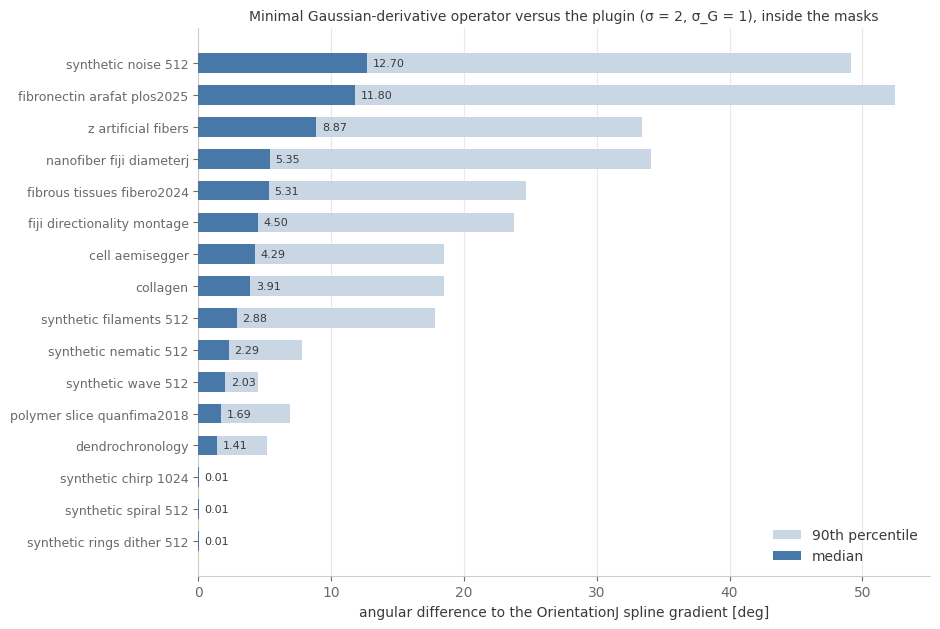

In [5]:
order = agreement['image'].tolist()
y = np.arange(len(order))
fig, ax = plt.subplots(figsize=(9.5, 6.4))
ax.barh(y, agreement['90th pct [deg]'], height=0.62, color='#c9d6e4',
        zorder=2, label='90th percentile')
ax.barh(y, agreement['median |dtheta| [deg]'], height=0.62, color=ACCENT,
        zorder=3, label='median')
for i, v in enumerate(agreement['median |dtheta| [deg]']):
    ax.annotate(f'{v:.2f}', (v, i), xytext=(4, 0), textcoords='offset points',
                va='center', fontsize=8, color='#3a3a37', zorder=4)
ax.set_yticks(y)
ax.set_yticklabels([n.replace('_', ' ') for n in order], fontsize=9)
ax.set_xlabel('angular difference to the OrientationJ spline gradient [deg]')
ax.set_title(f'Minimal Gaussian-derivative operator versus the plugin '
             f'(σ = {SIGMA:g}, σ_G = {SIGMA_GRADIENT:g}), inside the masks')
ax.grid(True, axis='x')
ax.set_axisbelow(True)
ax.legend(frameon=False, loc='lower right')
fig.tight_layout()
fig.savefig('operator-agreement.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Where does it differ, and why?

The gradient is the only difference, so the disagreement must grow where the
structures approach the pixel scale — the regime in which a Gaussian derivative
of width σ_G smooths what a spline derivative still resolves. The chirp makes
that visible directly, since its local period sweeps across the field, and the
effect is a choice, not a defect: a larger σ_G buys noise robustness at the cost
of fine detail.

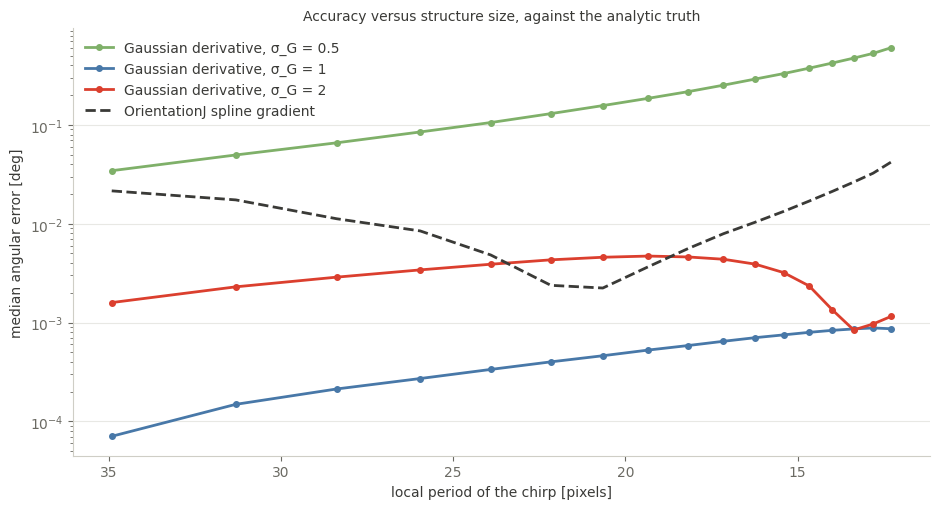

In [6]:
image = oj.load(os.path.join(INPUT, 'images', 'synthetic_chirp_1024.tif'))
mask = tifffile.imread(os.path.join(INPUT, 'masks',
                                    'synthetic_chirp_1024.tif')) > 0

# bin by radius, then label each bin by the local period, exactly as the
# gradient assessment does: frequency = FMIN + radius (FMAX - FMIN) / size
edges = np.linspace(0.05 * SIZE, 0.45 * SIZE, 18)
centres = 0.5 * (edges[:-1] + edges[1:])
periods = 1.0 / (FMIN + centres * (FMAX - FMIN) / SIZE)

fig, ax = plt.subplots(figsize=(9.5, 5.2))
for sigma_gradient, color, style in [(0.5, '#7fb069', '-'),
                                     (1.0, ACCENT, '-'),
                                     (2.0, SECOND, '-')]:
    _, _, theta = features(image, sigma=SIGMA, sigma_gradient=sigma_gradient)
    error = np.abs(axial_difference(theta, truth))
    curve = [np.median(error[mask & (radius >= lo) & (radius < hi)])
             for lo, hi in zip(edges[:-1], edges[1:])]
    ax.plot(periods, curve, style, color=color, lw=2.0, marker='o', ms=4,
            label=f'Gaussian derivative, σ_G = {sigma_gradient:g}')

reference = oj.analysis(image, sigma=SIGMA)
error = np.abs(axial_difference(reference['orientation'], truth))
curve = [np.median(error[mask & (radius >= lo) & (radius < hi)])
         for lo, hi in zip(edges[:-1], edges[1:])]
ax.plot(periods, curve, '--', color='#3a3a37', lw=2.0,
        label='OrientationJ spline gradient')

ax.set_yscale('log')
ax.invert_xaxis()
ax.set_xlabel('local period of the chirp [pixels]')
ax.set_ylabel('median angular error [deg]')
ax.set_title('Accuracy versus structure size, against the analytic truth')
ax.grid(True, axis='y')
ax.set_axisbelow(True)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig('operator-accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## The three features on a real image

Coherency, energy and orientation of `collagen`, computed by the minimal
operator, with the color survey built from them the way *Analysis* does it: hue
from the orientation, saturation from the coherency, brightness from the image.

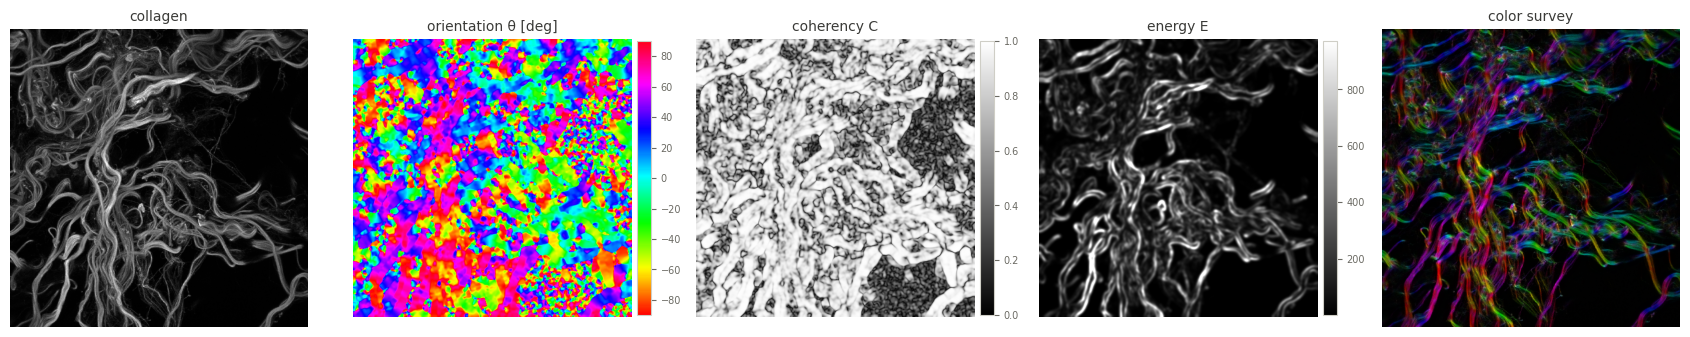

In [7]:
image = oj.load(os.path.join(INPUT, 'images', 'collagen.tif'))
C, E, theta = features(image, sigma=SIGMA, sigma_gradient=SIGMA_GRADIENT)
survey = oj.survey(image, {'orientation': theta.astype(np.float32),
                           'coherency': C.astype(np.float32)})

fig, axes = plt.subplots(1, 5, figsize=(17, 3.6))
for ax, (array, cmap, title, kw) in zip(axes, [
        (image, 'gray', 'collagen', {}),
        (np.degrees(theta), 'hsv', 'orientation θ [deg]', dict(vmin=-90, vmax=90)),
        (C, 'gray', 'coherency C', dict(vmin=0, vmax=1)),
        (E, 'gray', 'energy E', dict(vmax=np.percentile(E, 99.5))),
        (survey, None, 'color survey', {})]):
    m = ax.imshow(array, cmap=cmap, **kw)
    ax.set_title(title)
    ax.axis('off')
    if cmap in ('hsv', 'gray') and title != 'collagen':
        fig.colorbar(m, ax=ax, fraction=0.046, pad=0.02).ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig('operator-features.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

- **Exact where the truth is known.** Both kernels are normalized to machine
  precision, the gratings come back at exactly their imposed angle, and on the
  radial chirp the median error is **0.001°**. At σ_G = 1 the minimal operator is
  in fact an order of magnitude *more* accurate than the plugin's spline gradient
  on this smooth, band-limited pattern.
- **Indistinguishable from the plugin on smooth patterns**: the median angular
  difference is 0.006° on the rings, 0.009° on the spiral and 0.012° on the chirp.
- **Different by a few degrees on real textures**: from 1.4° (dendrochronology) to
  5.4° (nanofibers), and 12.7° on isotropic noise. The gradient is the only
  difference between the two implementations, so this is where a Gaussian
  derivative of width σ_G averages what a spline derivative still resolves — the
  disagreement grows as the structures approach the pixel scale, and on
  `synthetic_noise_512` there is no orientation to agree on in the first place.
  The energy maps stay strongly correlated throughout (0.64 to 0.94); the
  coherency correlation is only meaningful where coherency actually varies inside
  the mask, which is why the rings — where C ≈ 1 everywhere — report a
  coefficient close to zero.
- **σ_G is a choice, not a defect.** The accuracy curve shows σ_G = 0.5
  truncating the kernel too aggressively and σ_G = 2 flattening fine detail, with
  σ_G = 1 the sweet spot for this pattern. The same trade-off, across all five
  OrientationJ gradients, is quantified in the
  [gradient assessment](../gradients).
- Sixty lines of NumPy, four separable convolutions, no transform: enough to
  reproduce the measurement and to port it anywhere.